# Commissiestructuur & Invloed

**Thema:** Commissies, zetelverdelingen en voortouwcommissies.

**Kernvragen:** Welke vaste en tijdelijke commissies zijn het meest actief (krijgen de meeste zaken/activiteiten toebedeeld) en hoe is het verloop in vaste zetels en vacatures?

Dit notebook verkent o.a. de silver-tabellen `commissie`, `commissie_zetel`, `commissie_zetel_vast_persoon`, `commissie_zetel_vast_vacature` en `activiteit` (voortouwcommissie).

In [10]:
from pathlib import Path

import duckdb
import pandas as pd
import matplotlib.pyplot as plt

def find_database(start: Path | None = None) -> Path:
    """Find the repository DuckDB database by walking up from the current folder."""
    current = (start or Path.cwd()).resolve()
    for folder in (current, *current.parents):
        candidate = folder / "tweedekamer.duckdb"
        if candidate.is_file():
            return candidate
    raise FileNotFoundError("Could not find tweedekamer.duckdb from the current directory")


database_path = find_database()
connection = duckdb.connect(str(database_path), read_only=True)


def query_df(sql: str, parameters=None) -> pd.DataFrame:
    """Execute a SQL query and return the result as a pandas DataFrame."""
    return connection.execute(sql, parameters or []).fetchdf()


database_path

WindowsPath('C:/Users/Twan/tweedekamer-monitor/tweedekamer.duckdb')

## Onderwerp 1

In dit onderzoek staat de organisatie en invloed van parlementaire commissies centraal. Commissies bereiden veel parlementair werk voor en kunnen daarbij verschillende rollen hebben. De ene commissie is groot en heeft veel leden, terwijl een andere commissie kleiner is of tijdelijk wordt ingesteld. Ook kunnen commissies sterk verschillen in het aantal activiteiten en zaken waarvoor zij het voortouw hebben.
De deelvragen hieronder brengen deze verschillen systematisch in beeld. Daarbij wordt niet alleen gekeken naar aantallen, maar ook naar verloop, samenstelling en de mate waarin activiteiten daadwerkelijk worden uitgevoerd.

In [11]:
tabellen = query_df("""
  SELECT table_name
  FROM information_schema.tables
  WHERE table_schema = 'silver'
  ORDER BY table_name
""")

aantallen = pd.DataFrame(
    [(t, query_df(f"SELECT COUNT(*) AS n FROM silver.{t}")["n"][0]) for t in tabellen["table_name"]],
    columns=["tabel", "aantal_rijen"],
)
aantallen

,tabel,aantal_rijen
0,activiteit,73320
1,activiteit_actor,302137
2,activiteit_vervangen_vanuit,5894
3,activiteit_voortgezet_vanuit,620
4,agendapunt,321472
5,besluit,670814
6,besluit_zaak,670814
7,commissie,132
8,commissie_contactinformatie,458
9,commissie_zetel,8762


## 1. Welke soorten commissies zijn er, en hoeveel zijn nog actief?
We onderzoeken welke soorten commissies er zijn en hoeveel daarvan nog actief zijn. Door de commissies op basis van soort te groeperen, krijgen we inzicht in de structuur van het commissiestelsel. We tellen per soort hoeveel commissies er zijn en gebruiken datum_inactief om te bepalen of een commissie nog actief is. De resultaten laten zien dat sommige commissies geen ingevulde waarde bij soort hebben, waardoor deze categorie niet direct aan een specifiek type kan worden gekoppeld.

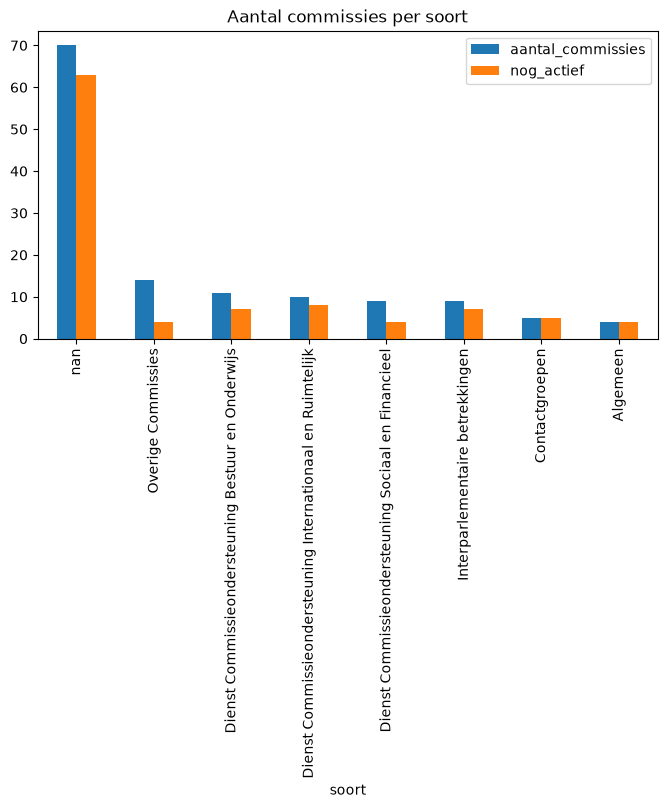

,soort,aantal_commissies,nog_actief
0,NaN,70,63
1,Overige Commissies,14,4
2,Dienst Commissieondersteuning Bestuur en Onder...,11,7
3,Dienst Commissieondersteuning Internationaal e...,10,8
4,Dienst Commissieondersteuning Sociaal en Finan...,9,4
5,Interparlementaire betrekkingen,9,7
6,Contactgroepen,5,5
7,Algemeen,4,4


In [12]:
soorten = query_df("""
  SELECT
    soort,
    COUNT(*) AS aantal_commissies,
    COUNT(*) FILTER (WHERE datum_inactief IS NULL) AS nog_actief
  FROM silver.commissie
  GROUP BY soort
  ORDER BY aantal_commissies DESC
""")

soorten.plot.bar(x="soort", y=["aantal_commissies", "nog_actief"], figsize=(8, 4),
                 title="Aantal commissies per soort")
plt.show()
soorten

## 2. Hoe groot zijn de commissies (aantal zetels)?
We onderzoeken welke commissies de meeste zetels hebben. Hiervoor tellen we per commissie het aantal zetels uit commissie_zetel en vergelijken we de commissies met elkaar. Zo wordt duidelijk welke commissies relatief groot zijn en welke kleiner.

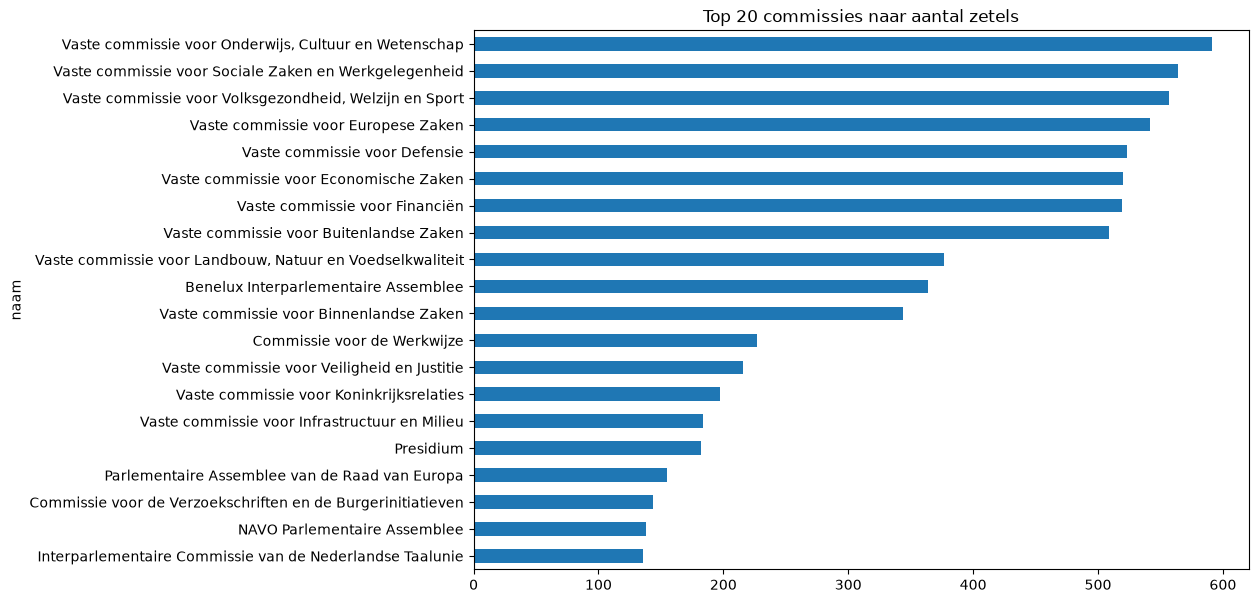

In [29]:
zetels = query_df("""
  SELECT
    c.naam_nl AS naam,
    c.soort,
    COUNT(z.id) AS aantal_zetels
  FROM silver.commissie c
  JOIN silver.commissie_zetel z ON z.commissie_id = c.id
  GROUP BY c.naam_nl, c.soort
  ORDER BY aantal_zetels DESC, c.naam_nl
  LIMIT 20
""")

zetels.sort_values("aantal_zetels").plot.barh(x="naam", y="aantal_zetels", figsize=(10, 7),
                                              title="Top 20 commissies naar aantal zetels", legend=False)
plt.show()

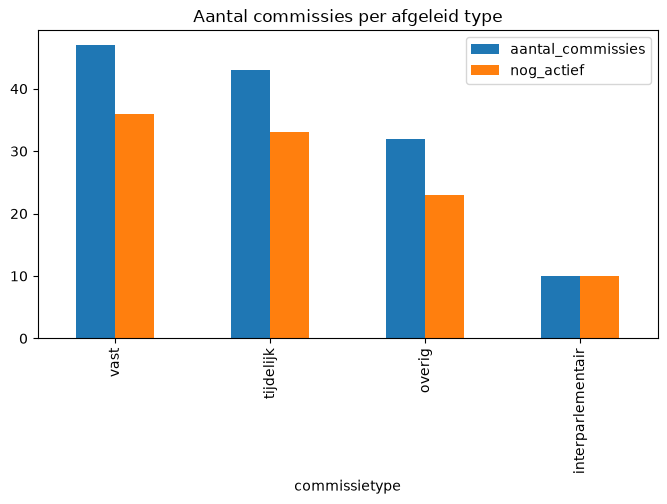

,commissietype,aantal_commissies,nog_actief
0,vast,47,36
1,tijdelijk,43,33
2,overig,32,23
3,interparlementair,10,10


In [36]:
COMMISSIE_TYPE = """
  CASE
    WHEN c.naam_nl ILIKE '%enquête%' OR c.naam_nl ILIKE '%tijdelijke%' THEN 'tijdelijk'
    WHEN c.naam_nl ILIKE 'vaste commissie%' OR c.naam_nl ILIKE 'algemene commissie%'
         OR c.naam_nl ILIKE 'commissie voor%' THEN 'vast'
    WHEN c.naam_nl ILIKE 'delegatie%' OR c.naam_nl ILIKE '%groep%' THEN 'interparlementair'
    ELSE 'overig'
  END
"""

typen = query_df(f"""
  SELECT
    {COMMISSIE_TYPE} AS commissietype,
    COUNT(*) AS aantal_commissies,
    COUNT(*) FILTER (WHERE c.datum_inactief IS NULL) AS nog_actief
  FROM silver.commissie c
  GROUP BY ALL
  ORDER BY aantal_commissies DESC
""")

typen.plot.bar(x="commissietype", y=["aantal_commissies", "nog_actief"], figsize=(8, 4),
               title="Aantal commissies per afgeleid type")
plt.show()
typen

## 3. Vacatures: waar zijn ze en hoe lang blijven ze open?
We onderzoeken waar de meeste vacatures voorkomen, hoe lang vacatures gemiddeld openstaan en hoe het aantal nieuwe vacatures zich per jaar ontwikkelt. Hiervoor gebruiken we de begin- en einddatum van vacatures. Als tot_en_met leeg is, rekenen we de vacature tot vandaag; hierdoor kunnen oude openstaande vacatures het gemiddelde beïnvloeden.

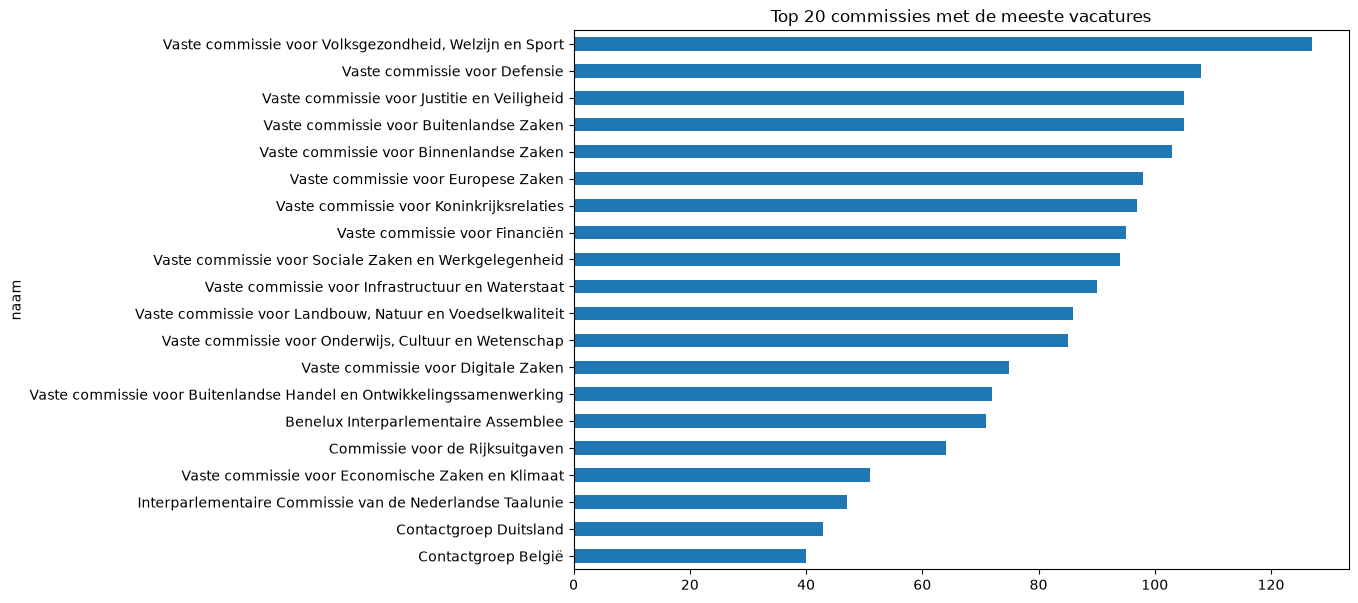

,naam,aantal_vacatures,nu_open,gem_dagen_open
0,"Vaste commissie voor Volksgezondheid, Welzijn ...",127,0,20.0
1,Vaste commissie voor Defensie,108,0,20.0
2,Vaste commissie voor Buitenlandse Zaken,105,0,20.0
3,Vaste commissie voor Justitie en Veiligheid,105,0,12.0
4,Vaste commissie voor Binnenlandse Zaken,103,0,15.0
5,Vaste commissie voor Europese Zaken,98,1,28.0
6,Vaste commissie voor Koninkrijksrelaties,97,1,28.0
7,Vaste commissie voor Financiën,95,0,16.0
8,Vaste commissie voor Sociale Zaken en Werkgele...,94,0,14.0
9,Vaste commissie voor Infrastructuur en Waterstaat,90,0,8.0


In [30]:
vacatures = query_df("""
  SELECT
    c.naam_nl AS naam,
    COUNT(*) AS aantal_vacatures,
    COUNT(*) FILTER (WHERE v.tot_en_met IS NULL) AS nu_open,
    ROUND(AVG(date_diff('day', CAST(v.van AS DATE),
                        COALESCE(CAST(v.tot_en_met AS DATE), current_date))), 0) AS gem_dagen_open
  FROM silver.commissie_zetel_vast_vacature v
  JOIN silver.commissie_zetel z ON z.id = v.commissie_zetel_id
  JOIN silver.commissie c ON c.id = z.commissie_id
  GROUP BY c.naam_nl
  ORDER BY aantal_vacatures DESC, c.naam_nl
  LIMIT 20
""")

vacatures.sort_values("aantal_vacatures").plot.barh(x="naam", y="aantal_vacatures", figsize=(10, 7),
                                                    title="Top 20 commissies met de meeste vacatures", legend=False)
plt.show()
vacatures

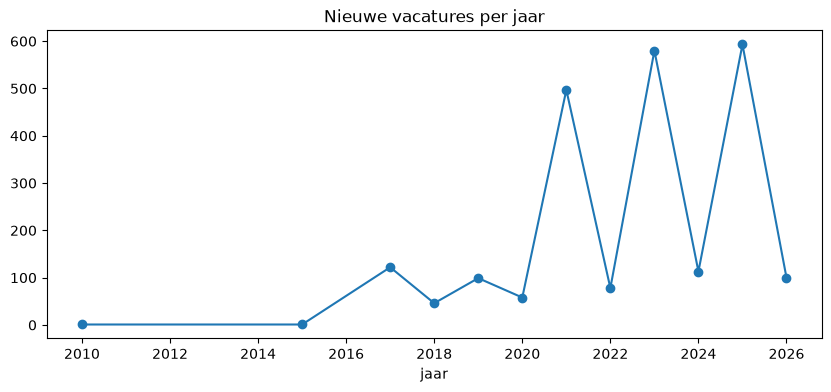

In [15]:
vacatures_per_jaar = query_df("""
  SELECT
    year(CAST(van AS DATE)) AS jaar,
    COUNT(*) AS nieuwe_vacatures
  FROM silver.commissie_zetel_vast_vacature
  WHERE van IS NOT NULL
  GROUP BY jaar
  ORDER BY jaar
""")

vacatures_per_jaar.plot(x="jaar", y="nieuwe_vacatures", marker="o", figsize=(10, 4),
                        title="Nieuwe vacatures per jaar", legend=False)
plt.show()

## 4. Verloop in vaste zetels
We onderzoeken hoeveel leden jaarlijks bij commissies komen en vertrekken en hoe lang leden gemiddeld in een commissie zitten. Hiervoor gebruiken we van als startdatum en tot_en_met als einddatum van een zitting. Door de zittingsduur per commissie te vergelijken, zien we waar relatief veel wisselingen plaatsvinden.

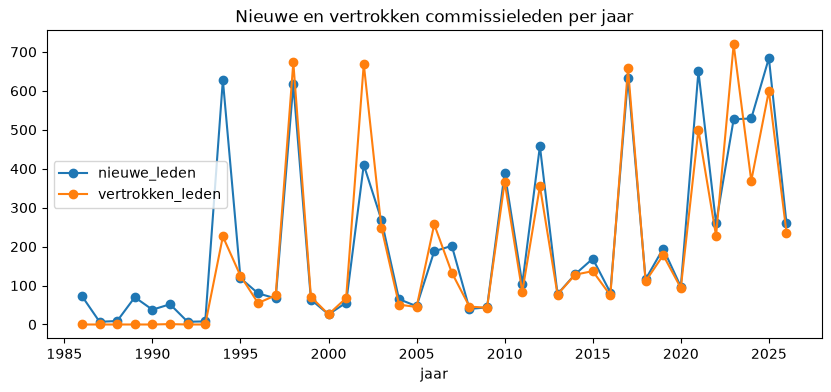

In [16]:
verloop = query_df("""
  WITH start AS (
    SELECT year(CAST(van AS DATE)) AS jaar, COUNT(*) AS n
    FROM silver.commissie_zetel_vast_persoon WHERE van IS NOT NULL GROUP BY 1
  ),
  einde AS (
    SELECT year(CAST(tot_en_met AS DATE)) AS jaar, COUNT(*) AS n
    FROM silver.commissie_zetel_vast_persoon WHERE tot_en_met IS NOT NULL GROUP BY 1
  )
  SELECT
    COALESCE(start.jaar, einde.jaar) AS jaar,
    COALESCE(start.n, 0) AS nieuwe_leden,
    COALESCE(einde.n, 0) AS vertrokken_leden
  FROM start FULL OUTER JOIN einde ON start.jaar = einde.jaar
  ORDER BY jaar
""")

verloop.plot(x="jaar", y=["nieuwe_leden", "vertrokken_leden"], marker="o", figsize=(10, 4),
             title="Nieuwe en vertrokken commissieleden per jaar")
plt.show()

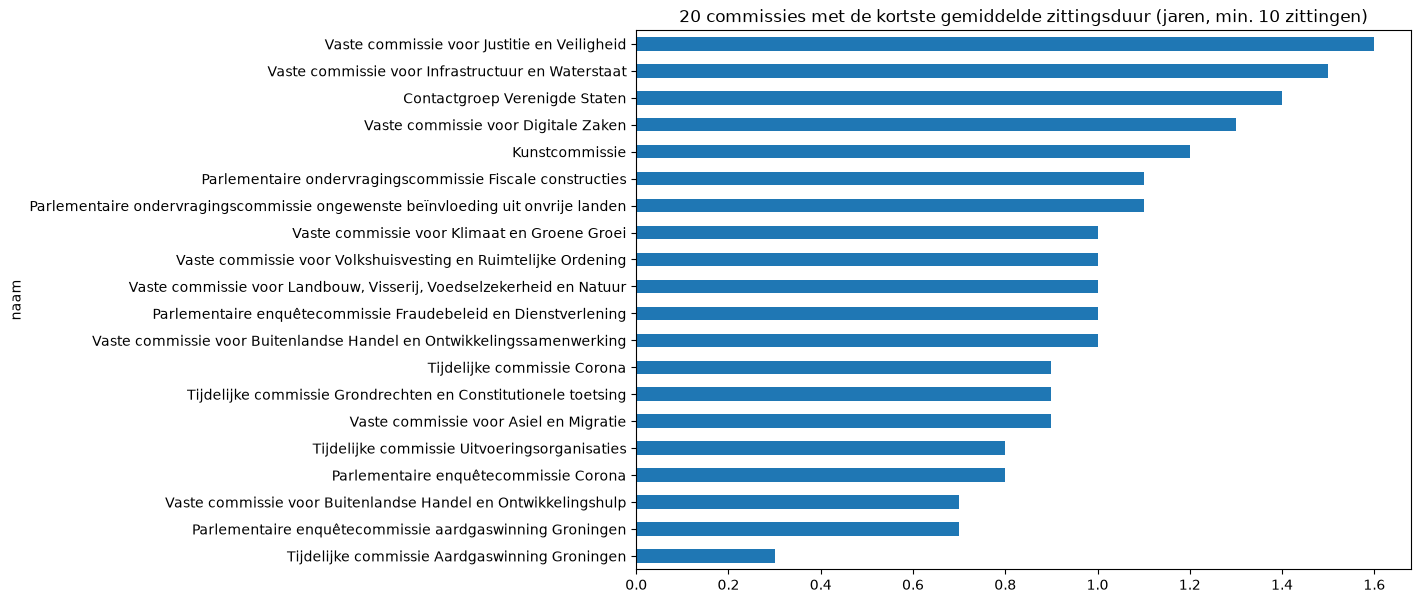

In [31]:
zittingsduur = query_df("""
  SELECT
    c.naam_nl AS naam,
    COUNT(*) AS aantal_zittingen,
    ROUND(AVG(date_diff('day', CAST(zp.van AS DATE),
                        COALESCE(CAST(zp.tot_en_met AS DATE), current_date))) / 365.25, 1) AS gem_jaren
  FROM silver.commissie_zetel_vast_persoon zp
  JOIN silver.commissie_zetel z ON z.id = zp.commissie_zetel_id
  JOIN silver.commissie c ON c.id = z.commissie_id
  WHERE zp.van IS NOT NULL
  GROUP BY c.naam_nl
  HAVING COUNT(*) >= 10
  ORDER BY gem_jaren
  LIMIT 20
""")

zittingsduur.plot.barh(x="naam", y="gem_jaren", figsize=(10, 7), legend=False,
                       title="20 commissies met de kortste gemiddelde zittingsduur (jaren, min. 10 zittingen)")
plt.show()

## 5. Geslachtsverhouding binnen de commissies
We onderzoeken hoe de verhouding tussen mannen en vrouwen is binnen de huidige commissies. We gebruiken alleen huidige leden van actieve commissies en koppelen deze aan persoon om het geslacht te bepalen. De resultaten worden alleen getoond voor commissies met minimaal 5 leden, zodat kleine commissies minder zwaar meetellen.

In [18]:
query_df("""
  SELECT geslacht, COUNT(*) AS aantal
  FROM silver.persoon
  GROUP BY geslacht
  ORDER BY aantal DESC
""")

,geslacht,aantal
0,man,2508
1,vrouw,574
2,x,1


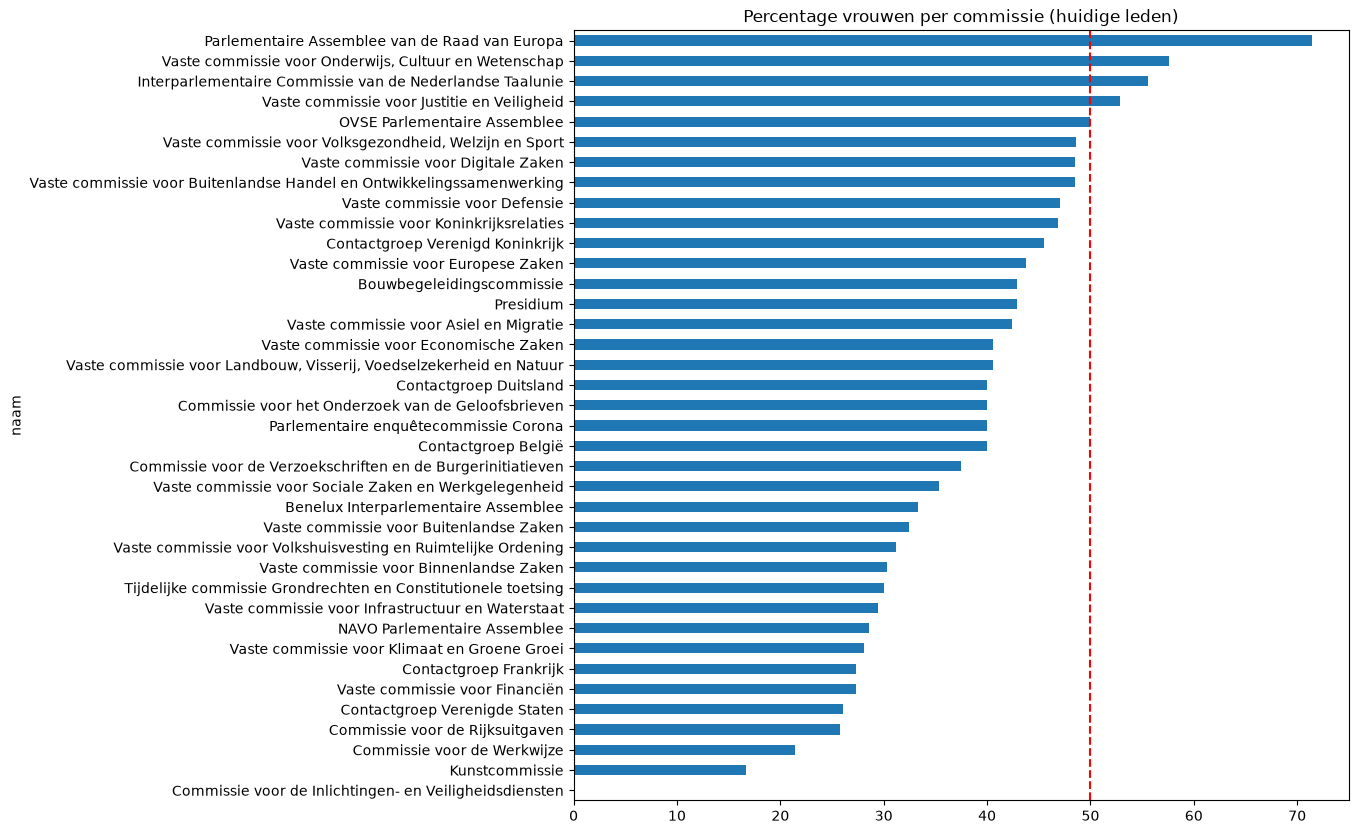

,vrouwen,mannen,totaal,pct_vrouw
count,38.000000,38.000000,38.000000,38.000000
mean,8.342105,12.815789,21.447368,38.065789
std,5.547224,7.410202,12.184832,12.777224
min,0.000000,2.000000,5.000000,0.000000
25%,3.000000,5.000000,8.250000,29.550000
50%,7.000000,14.500000,27.000000,40.000000
75%,13.000000,19.000000,33.000000,46.550000
max,19.000000,24.000000,35.000000,71.400000


In [32]:
geslacht = query_df("""
  SELECT
    c.naam_nl AS naam,
    COUNT(DISTINCT p.id) FILTER (WHERE p.geslacht ILIKE 'vrouw%') AS vrouwen,
    COUNT(DISTINCT p.id) FILTER (WHERE p.geslacht ILIKE 'man%') AS mannen,
    COUNT(DISTINCT p.id) AS totaal
  FROM silver.commissie_zetel_vast_persoon zp
  JOIN silver.commissie_zetel z ON z.id = zp.commissie_zetel_id
  JOIN silver.commissie c ON c.id = z.commissie_id
  JOIN silver.persoon p ON p.id = zp.persoon_id
  WHERE zp.tot_en_met IS NULL AND c.datum_inactief IS NULL
  GROUP BY c.naam_nl
  HAVING COUNT(DISTINCT p.id) >= 5
""")

geslacht["pct_vrouw"] = (100 * geslacht["vrouwen"] / geslacht["totaal"]).round(1)
geslacht = geslacht.sort_values("pct_vrouw")

geslacht.plot.barh(x="naam", y="pct_vrouw", figsize=(10, 10), legend=False,
                   title="Percentage vrouwen per commissie (huidige leden)")
plt.axvline(50, color="red", linestyle="--")
plt.show()
geslacht.describe()

### Wie zijn de voorzitters?

**Vraag:** zijn voorzitters vaker man dan vrouw, vergeleken met gewone leden?

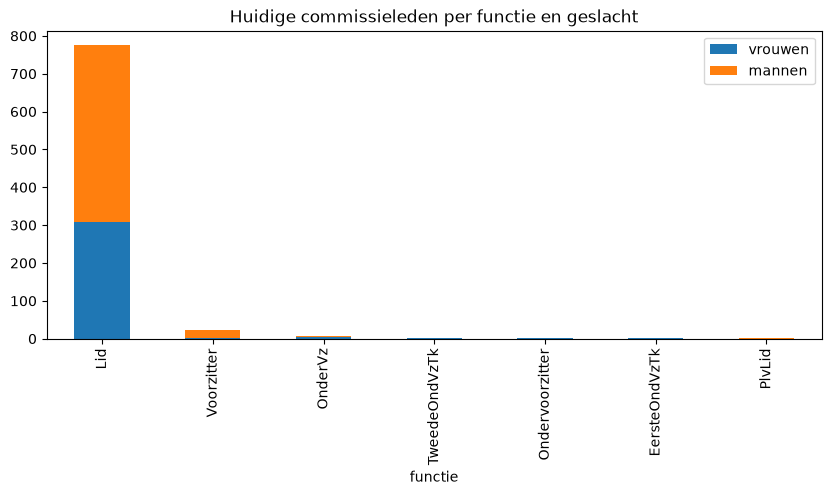

,functie,vrouwen,mannen,totaal
0,Lid,309,466,786
1,Voorzitter,3,19,22
2,OnderVz,4,4,8
3,TweedeOndVzTk,1,0,1
4,Ondervoorzitter,1,0,1
5,EersteOndVzTk,1,0,1
6,PlvLid,0,1,1


In [20]:
functies = query_df("""
  SELECT
    zp.functie,
    COUNT(*) FILTER (WHERE p.geslacht ILIKE 'vrouw%') AS vrouwen,
    COUNT(*) FILTER (WHERE p.geslacht ILIKE 'man%') AS mannen,
    COUNT(*) AS totaal
  FROM silver.commissie_zetel_vast_persoon zp
  JOIN silver.persoon p ON p.id = zp.persoon_id
  WHERE zp.tot_en_met IS NULL
  GROUP BY zp.functie
  ORDER BY totaal DESC
""")

functies.plot.bar(x="functie", y=["vrouwen", "mannen"], stacked=True, figsize=(10, 4),
                  title="Huidige commissieleden per functie en geslacht")
plt.show()
functies

## 6. Leeftijdsverdeling binnen de commissies
We onderzoeken of de verdeling tussen mannen en vrouwen bij voorzitters verschilt van die bij gewone commissieleden. Hiervoor vergelijken we de beschikbare gegevens over voorzitters met de geslachtsverdeling binnen de commissies.

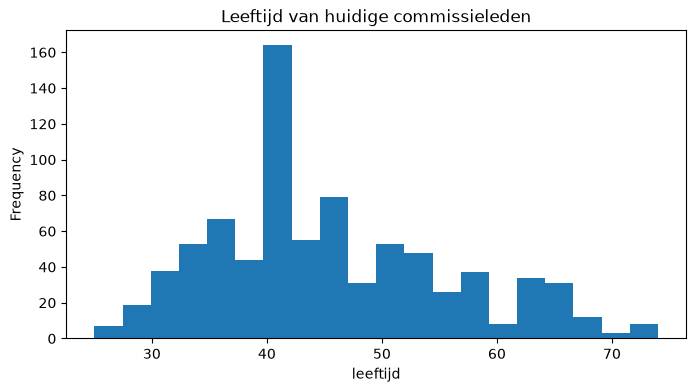

In [33]:
leeftijden = query_df("""
  SELECT DISTINCT
    c.naam_nl AS naam,
    p.id AS persoon_id,
    date_sub('year', CAST(p.geboortedatum AS DATE), current_date) AS leeftijd
  FROM silver.commissie_zetel_vast_persoon zp
  JOIN silver.commissie_zetel z ON z.id = zp.commissie_zetel_id
  JOIN silver.commissie c ON c.id = z.commissie_id
  JOIN silver.persoon p ON p.id = zp.persoon_id
  WHERE zp.tot_en_met IS NULL
    AND c.datum_inactief IS NULL
    AND p.geboortedatum IS NOT NULL
""")

leeftijden["leeftijd"].plot.hist(bins=20, figsize=(8, 4), title="Leeftijd van huidige commissieleden")
plt.xlabel("leeftijd")
plt.show()

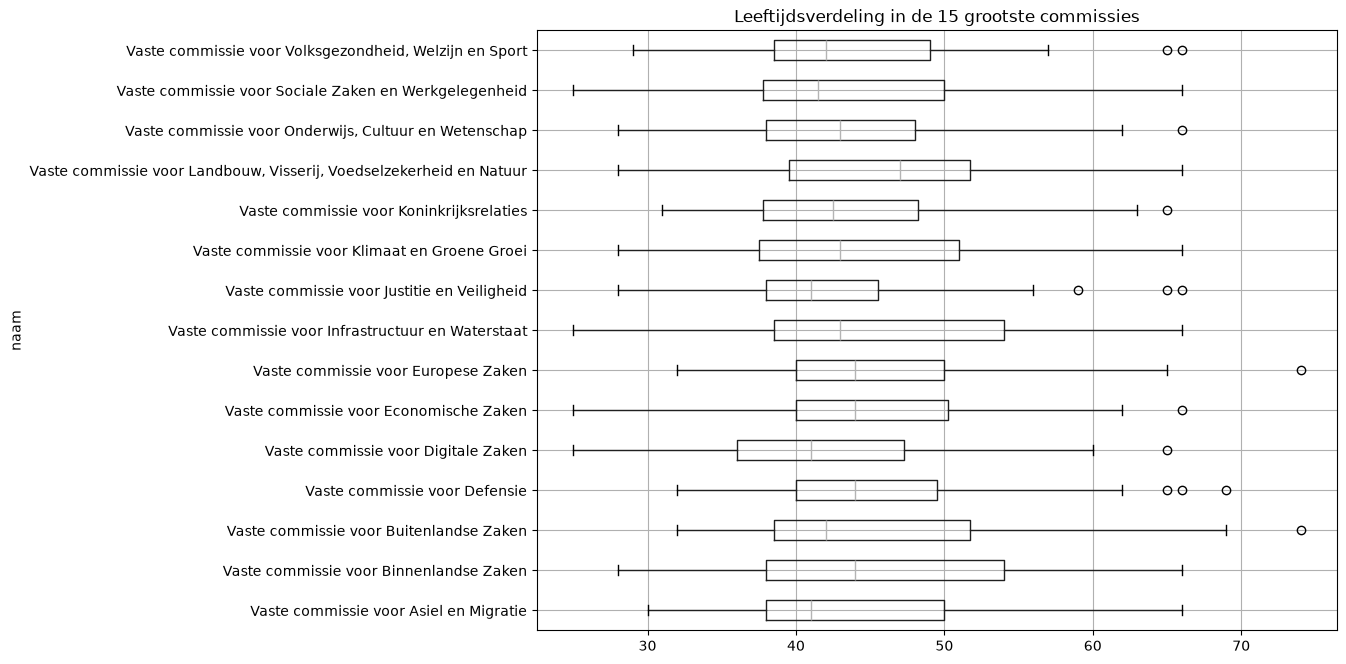

,leden,gemiddeld,mediaan,jongste,oudste
naam,,,,,
Parlementaire enquêtecommissie Corona,5,36.8,34.0,32,46
Commissie voor het Onderzoek van de Geloofsbrieven,5,37.8,38.0,28,46
Contactgroep Verenigd Koninkrijk,11,40.8,38.0,33,66
Vaste commissie voor Digitale Zaken,32,42.5,41.0,25,65
Vaste commissie voor Justitie en Veiligheid,34,42.9,41.0,28,66
Kunstcommissie,6,43.2,40.5,37,57
Commissie voor de Verzoekschriften en de Burgerinitiatieven,8,43.4,41.5,32,59
Vaste commissie voor Volkshuisvesting en Ruimtelijke Ordening,32,43.8,43.0,28,66
Vaste commissie voor Sociale Zaken en Werkgelegenheid,34,44.1,41.5,25,66


In [34]:
top15 = leeftijden["naam"].value_counts().head(15).index
leeftijden[leeftijden["naam"].isin(top15)].boxplot(column="leeftijd", by="naam", vert=False, figsize=(10, 8))
plt.suptitle("")
plt.title("Leeftijdsverdeling in de 15 grootste commissies")
plt.show()

(leeftijden.groupby("naam")["leeftijd"]
    .agg(leden="count", gemiddeld="mean", mediaan="median", jongste="min", oudste="max")
    .round(1)
    .sort_values("gemiddeld"))

## 7. Welke commissies zijn het meest actief?
We onderzoeken welke commissies het vaakst als voortouwcommissie bij activiteiten optreden. Hiervoor gebruiken we de tabel activiteit en tellen we per commissie het aantal activiteiten. Zo kunnen we zien welke commissies het meest betrokken zijn bij activiteiten.

In [23]:
query_df("""
  SELECT column_name
  FROM information_schema.columns
  WHERE table_schema = 'silver' AND table_name = 'activiteit'
    AND (column_name ILIKE '%voortouw%' OR column_name ILIKE '%commissie%')
""")

,column_name
0,sid_voortouw
1,voortouwnaam
2,voortouwafkorting
3,voortouwkortenaam
4,voortouwcommissie_id


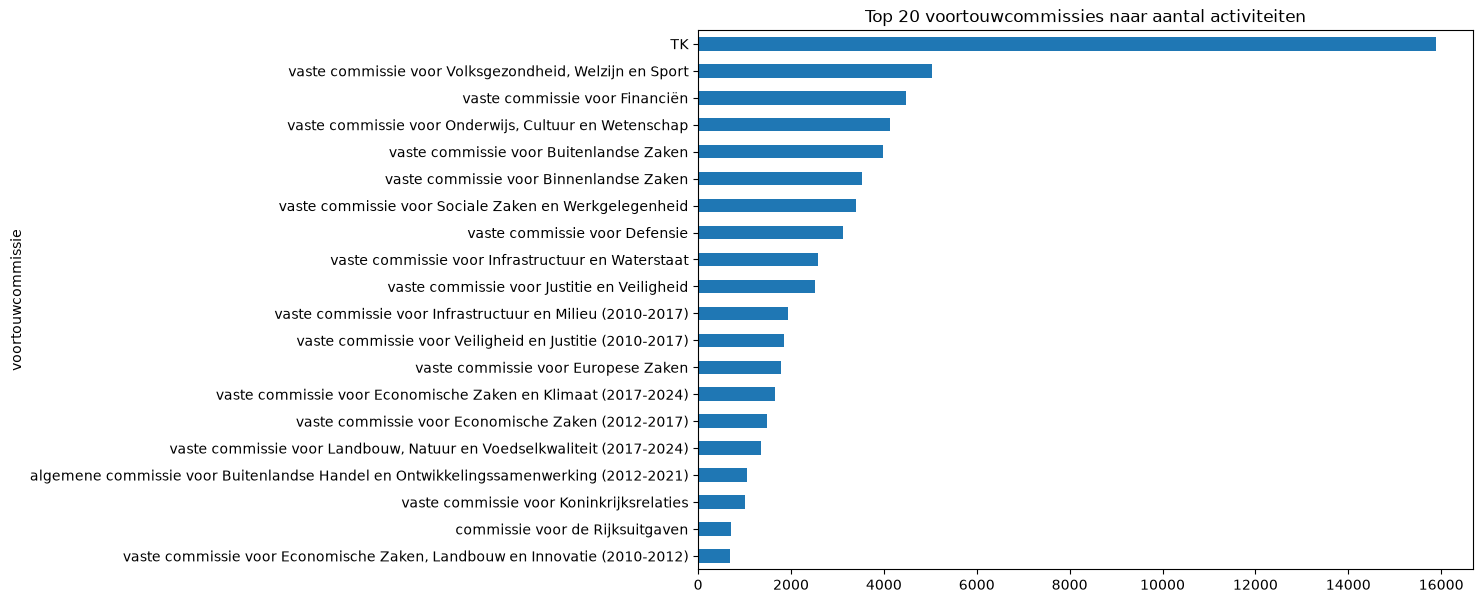

In [24]:
VOORTOUW = "voortouwnaam"  # pas aan als de kolom in de uitvoer hierboven anders heet

voortouw = query_df(f"""
  SELECT
    {VOORTOUW} AS voortouwcommissie,
    COUNT(*) AS aantal_activiteiten
  FROM silver.activiteit
  WHERE {VOORTOUW} IS NOT NULL
  GROUP BY 1
  ORDER BY aantal_activiteiten DESC
  LIMIT 20
""")

voortouw.sort_values("aantal_activiteiten").plot.barh(x="voortouwcommissie", y="aantal_activiteiten",
                                                      figsize=(10, 7), legend=False,
                                                      title="Top 20 voortouwcommissies naar aantal activiteiten")
plt.show()

 ### 7b. Meest actieve vaste en tijdelijke commissies

We vergelijken de activiteit van vaste en tijdelijke commissies afzonderlijk. Daarbij koppelen we via voortouwcommissie_id aan commissie, zodat TK niet als commissie wordt meegerekend. Zo ontstaat een eerlijker beeld van welke vaste en tijdelijke commissies het meest actief zijn.

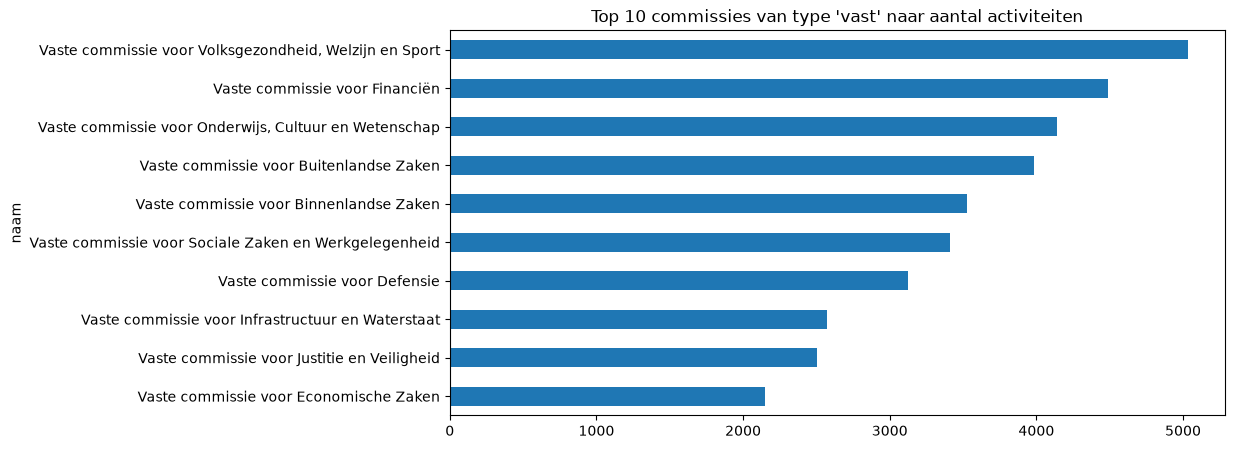

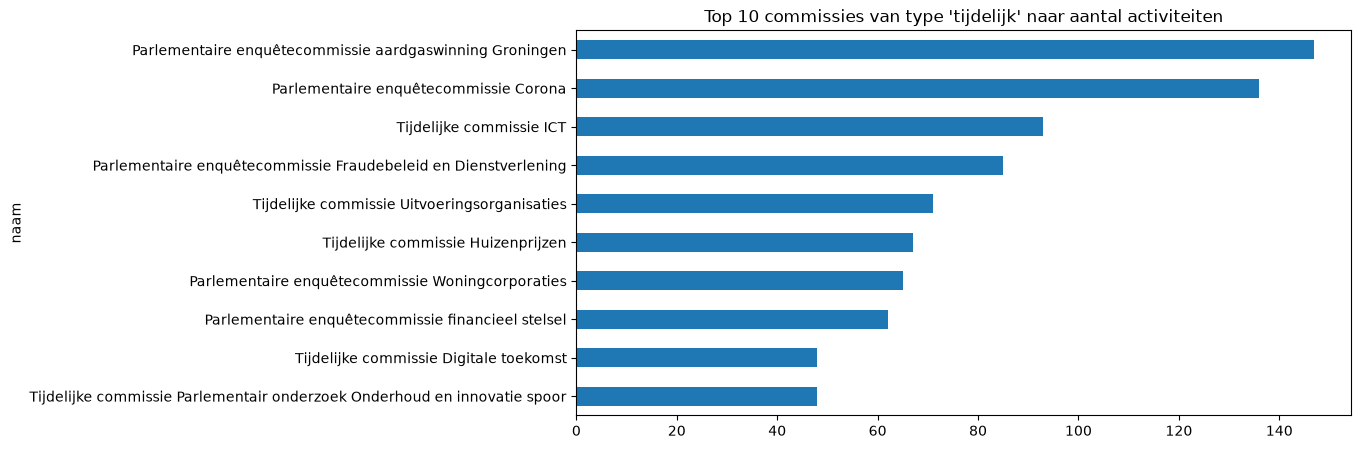

In [37]:
activiteiten = query_df(f"""
  SELECT
    c.naam_nl AS naam,
    {COMMISSIE_TYPE} AS commissietype,
    COUNT(*) AS aantal_activiteiten
  FROM silver.activiteit a
  JOIN silver.commissie c ON c.id = a.voortouwcommissie_id
  GROUP BY ALL
  ORDER BY aantal_activiteiten DESC
""")

for soort in ["vast", "tijdelijk"]:
    deel = activiteiten[activiteiten["commissietype"] == soort].head(10)
    if deel.empty:
        print(f"Geen commissies van type '{soort}' met activiteiten.")
        continue
    deel.sort_values("aantal_activiteiten").plot.barh(
        x="naam", y="aantal_activiteiten", figsize=(10, 5), legend=False,
        title=f"Top 10 commissies van type '{soort}' naar aantal activiteiten")
    plt.show()

## 7C
We onderzoeken ook hoeveel zaken aan commissies gekoppeld zijn. Hiervoor volgen we de keten commissie → activiteit → agendapunt → besluit → besluit_zaak. Alleen zaken waarover een besluit is genomen tellen mee. Hierbij zijn de exacte kolomnamen van enkele tabellen een aandachtspunt, omdat deze niet vooraf zijn gecontroleerd.

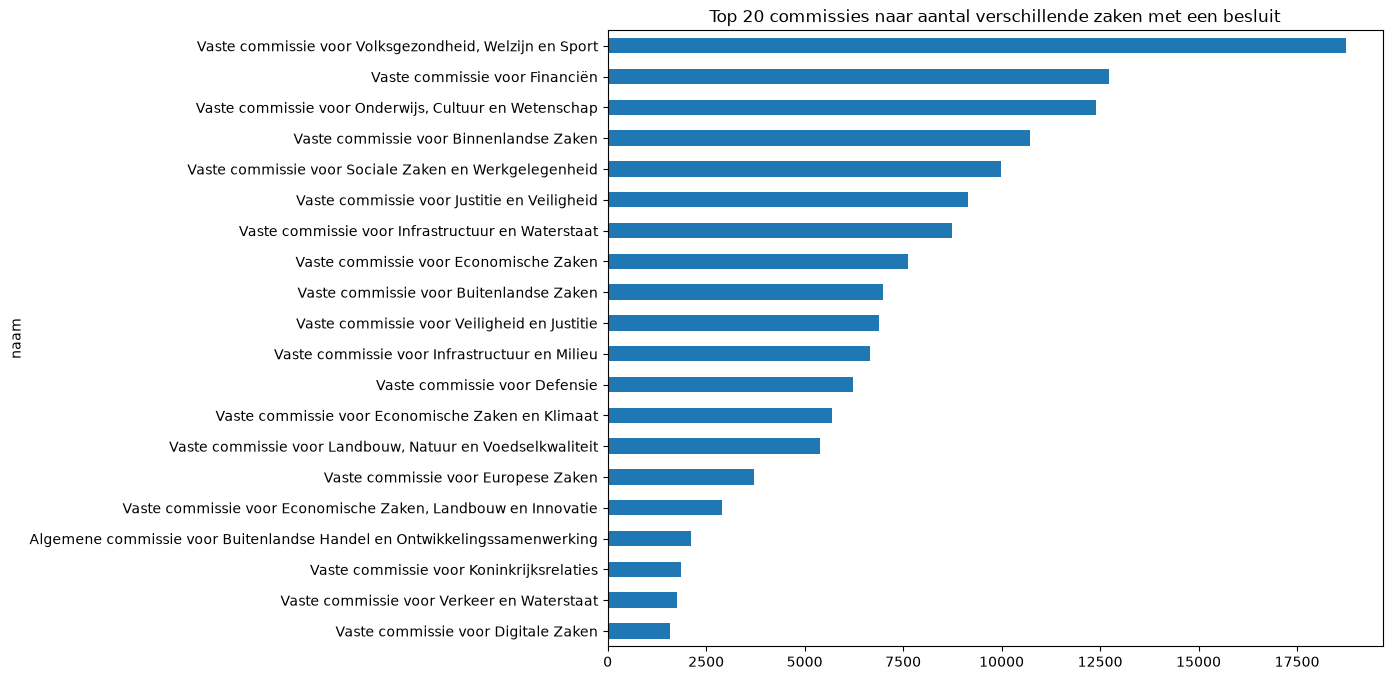

In [38]:
zaken = query_df(f"""
  SELECT
    c.naam_nl AS naam,
    {COMMISSIE_TYPE} AS commissietype,
    COUNT(DISTINCT bz.zaak_id) AS aantal_zaken
  FROM silver.activiteit a
  JOIN silver.commissie c ON c.id = a.voortouwcommissie_id
  JOIN silver.agendapunt ap ON ap.activiteit_id = a.id
  JOIN silver.besluit b ON b.agendapunt_id = ap.id
  JOIN silver.besluit_zaak bz ON bz.besluit_id = b.id
  GROUP BY ALL
  ORDER BY aantal_zaken DESC
""")

zaken.head(20).sort_values("aantal_zaken").plot.barh(
    x="naam", y="aantal_zaken", figsize=(10, 8), legend=False,
    title="Top 20 commissies naar aantal verschillende zaken met een besluit")
plt.show()

## 8. Welke commissies zijn het meest effectief?
We onderzoeken welke commissies het meest effectief lijken op basis van de beschikbare gegevens. Omdat effectiviteit niet direct meetbaar is, kijken we naar het aantal activiteiten en naar het aandeel activiteiten dat is uitgevoerd tegenover geannuleerde of vervallen activiteiten. Dit geeft een indicatie van effectiviteit, maar is geen direct bewijs dat een commissie beter werkt dan een andere.

In [25]:
query_df("""
  SELECT status, COUNT(*) AS aantal
  FROM silver.activiteit
  GROUP BY status
  ORDER BY aantal DESC
""")

,status,aantal
0,Uitgevoerd,60862
1,Verplaatst,5764
2,Geannuleerd,4997
3,Gepland,920
4,Vervallen,777


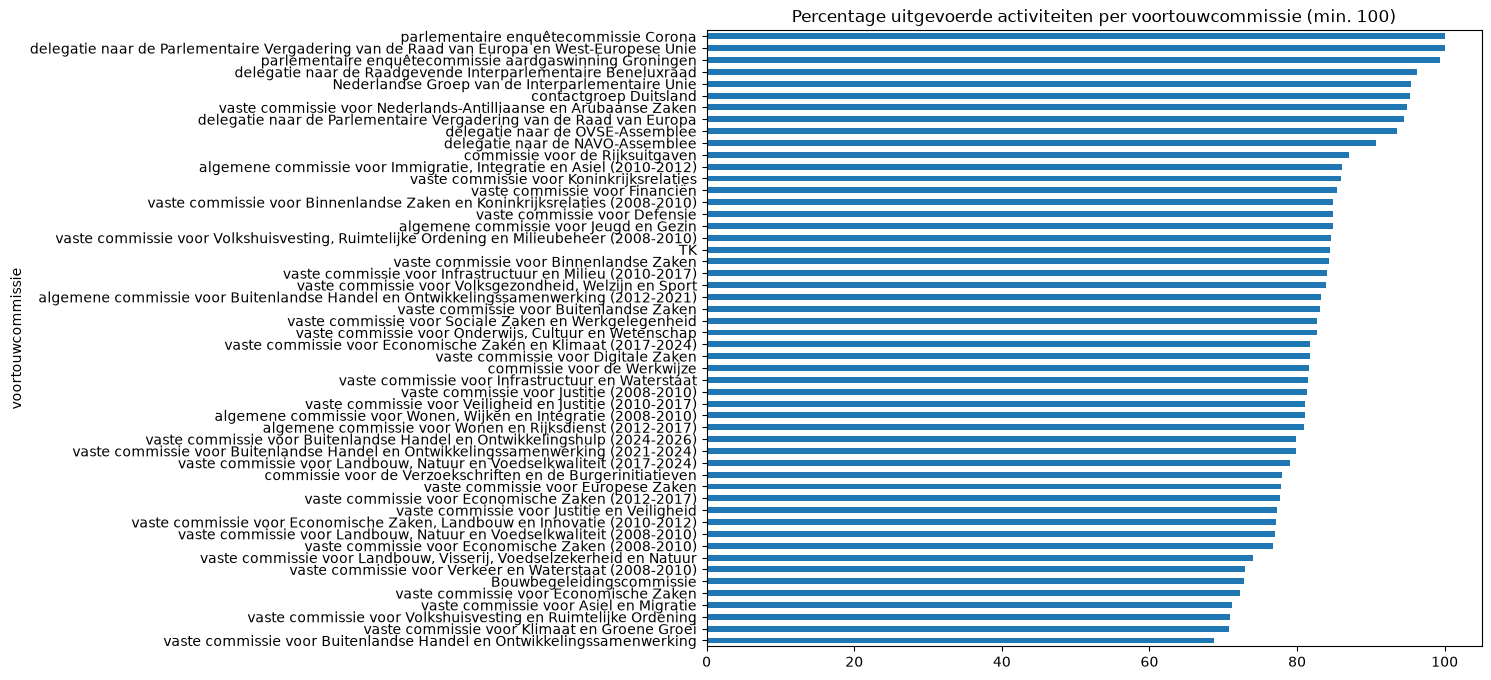

,voortouwcommissie,totaal,uitgevoerd,pct_uitgevoerd
0,parlementaire enquêtecommissie Corona,136,136,100.0
1,delegatie naar de Parlementaire Vergadering va...,168,168,100.0
2,parlementaire enquêtecommissie aardgaswinning ...,147,146,99.3
3,delegatie naar de Raadgevende Interparlementai...,164,158,96.3
4,Nederlandse Groep van de Interparlementaire Unie,200,191,95.5
5,contactgroep Duitsland,106,101,95.3
6,vaste commissie voor Nederlands-Antilliaanse e...,117,111,94.9
7,delegatie naar de Parlementaire Vergadering va...,582,550,94.5
8,delegatie naar de OVSE-Assemblee,283,265,93.6
9,delegatie naar de NAVO-Assemblee,387,351,90.7


In [26]:
effectief = query_df(f"""
  SELECT
    {VOORTOUW} AS voortouwcommissie,
    COUNT(*) AS totaal,
    COUNT(*) FILTER (WHERE status ILIKE 'uitgevoerd') AS uitgevoerd,
    ROUND(100.0 * COUNT(*) FILTER (WHERE status ILIKE 'uitgevoerd') / COUNT(*), 1) AS pct_uitgevoerd
  FROM silver.activiteit
  WHERE {VOORTOUW} IS NOT NULL
  GROUP BY 1
  HAVING COUNT(*) >= 100
  ORDER BY pct_uitgevoerd DESC
""")

effectief.sort_values("pct_uitgevoerd").plot.barh(x="voortouwcommissie", y="pct_uitgevoerd",
                                                  figsize=(10, 8), legend=False,
                                                  title="Percentage uitgevoerde activiteiten per voortouwcommissie (min. 100)")
plt.show()
effectief

## 9. Datakwaliteit
We controleren de data op mogelijke onvolkomenheden en opvallende waarden. Zo kunnen we bepalen waar ontbrekende of afwijkende gegevens voorkomen en of deze mogelijk door de brondata of door het ETL-proces zijn ontstaan. Uit de controle blijkt dat er geen ontbrekende gegevens zijn gevonden.

In [27]:
kwaliteit = query_df("""
  SELECT
    (SELECT COUNT(*) - COUNT(DISTINCT id) FROM silver.commissie_zetel_vast_persoon) AS dubbele_id_zitting,
    (SELECT COUNT(*) FROM silver.commissie_zetel_vast_persoon WHERE tot_en_met < van) AS zitting_einde_voor_start,
    (SELECT COUNT(*) FROM silver.commissie_zetel_vast_persoon WHERE persoon_id IS NULL) AS zitting_zonder_persoon,
    (SELECT COUNT(*) FROM silver.commissie_zetel_vast_vacature WHERE tot_en_met < van) AS vacature_einde_voor_start,
    (SELECT COUNT(*) FROM silver.persoon WHERE geboortedatum IS NULL) AS persoon_zonder_geboortedatum,
    (SELECT COUNT(*) FROM silver.persoon WHERE geslacht IS NULL) AS persoon_zonder_geslacht,
    (SELECT COUNT(*) FROM silver.commissie_zetel z
       LEFT JOIN silver.commissie c ON c.id = z.commissie_id WHERE c.id IS NULL) AS zetel_zonder_commissie
""")
kwaliteit.T.rename(columns={0: "aantal"})

,aantal
dubbele_id_zitting,0
zitting_einde_voor_start,17
zitting_zonder_persoon,0
vacature_einde_voor_start,149
persoon_zonder_geboortedatum,3
persoon_zonder_geslacht,0
zetel_zonder_commissie,0


In [35]:
# Onwaarschijnlijke leeftijden onder de huidige commissieleden
leeftijden[(leeftijden["leeftijd"] < 18) | (leeftijden["leeftijd"] > 90)]

,naam,persoon_id,leeftijd


## Conclusies